# LAB 02 — N-gram Language Models

Corpus: 10.000 documents đầu tiên từ C4. Notebook trình bày các thực nghiệm theo thứ tự mục 13–23 của W2. Các bảng và biểu đồ hiện trực tiếp trong notebook; chỉ bảng dữ liệu kết quả được ghi vào results.csv.


In [1]:
from __future__ import annotations

import csv
import gc
import gzip
import json
import math
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_lab_directory():
    current = Path.cwd().resolve()
    for base in (current, *current.parents):
        if base.name == "lab2" and (base / "ngram_lm.py").is_file():
            return base
        candidate = base / "lab2"
        if (candidate / "ngram_lm.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from lab2 or its parent folder")


LAB_DIR = find_lab_directory()
REPO_ROOT = LAB_DIR.parent
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from ngram_lm import (
    NGramLanguageModel, build_vocabulary, document_to_sentences,
    tokenize_sentence, train_bigram, train_trigram, train_unigram,
)

DATA_PATH = REPO_ROOT / "lab01" / "data" / "c4-train.00000-of-01024-30K.json.gz"
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Corpus not found: {DATA_PATH}")

MAX_DOCUMENTS = 10_000
RANDOM_SEED = 42
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
RESULTS_PATH = LAB_DIR / "results.csv"

RESULT_COLUMNS = [
    "record_type", "experiment", "model", "n", "smoothing", "split",
    "context", "candidate", "rank", "prediction", "actual_next_word",
    "probability", "perplexity", "notes",
]
all_result_rows = []

def show_table(table):
    print(table.to_string(index=True, max_rows=None, max_cols=None))



def add_result(record_type, experiment, model="", n="", smoothing="", split="",
               context="", candidate="", rank="", prediction="",
               actual_next_word="", probability="", perplexity="", notes=""):
    all_result_rows.append({
        "record_type": record_type, "experiment": experiment, "model": model,
        "n": n, "smoothing": smoothing, "split": split, "context": context,
        "candidate": candidate, "rank": rank, "prediction": prediction,
        "actual_next_word": actual_next_word, "probability": probability,
        "perplexity": perplexity, "notes": notes,
    })

print(f"Corpus: {DATA_PATH}")
print(f"Documents: first {MAX_DOCUMENTS:,}; seed={RANDOM_SEED}; split=70/15/15")


Corpus: D:\NLP_exercise\lab01\data\c4-train.00000-of-01024-30K.json.gz

Documents: first 10,000; seed=42; split=70/15/15



## 0. Corpus và tiền xử lý

Dữ liệu được lấy từ tệp JSON nén của lab01. Từng document được chuyển thành các câu; token được viết thường và chỉ giữ chữ/số ASCII cùng dấu nháy trong từ. Mỗi câu được đếm n-gram riêng. Tách train/validation/test theo document với seed 42 và tỉ lệ 70/15/15.


In [2]:
def load_documents(path, limit):
    documents = []
    with gzip.open(path, "rt", encoding="utf-8") as stream:
        for line in stream:
            if len(documents) >= limit:
                break
            if not line.strip():
                continue
            record = json.loads(line)
            text = record.get("text", "") if isinstance(record, dict) else ""
            documents.append(document_to_sentences(text if isinstance(text, str) else ""))
    return documents


def flatten_documents(items):
    return [sentence for document in items for sentence in document]


documents = load_documents(DATA_PATH, MAX_DOCUMENTS)
all_sentences = flatten_documents(documents)
indices = np.random.default_rng(RANDOM_SEED).permutation(len(documents))
train_end = int(TRAIN_FRACTION * len(documents))
validation_end = int((TRAIN_FRACTION + VALIDATION_FRACTION) * len(documents))
train_documents = [documents[i] for i in indices[:train_end]]
validation_documents = [documents[i] for i in indices[train_end:validation_end]]
test_documents = [documents[i] for i in indices[validation_end:]]
train_sentences = flatten_documents(train_documents)
validation_sentences = flatten_documents(validation_documents)
test_sentences = flatten_documents(test_documents)

print(f"Documents: {len(documents):,} total | {len(train_documents):,} train | {len(validation_documents):,} validation | {len(test_documents):,} test")
print(f"Sentences: {len(all_sentences):,}")
print(f"Tokens: {sum(map(len, all_sentences)):,}")
print(f"Train/validation/test sentences: {len(train_sentences):,} / {len(validation_sentences):,} / {len(test_sentences):,}")


Documents: 10,000 total | 7,000 train | 1,500 validation | 1,500 test

Sentences: 207,954

Tokens: 3,634,369

Train/validation/test sentences: 145,151 / 31,255 / 31,548



## 13. Experiment 1 — Corpus statistics

Thống kê corpus, số loại unigram/bigram/trigram, số n-gram xuất hiện đúng một lần và phân bố tần suất trên 10.000 documents.


In [3]:
corpus_statistics = pd.DataFrame({
    "Statistic": ["Number of documents", "Number of sentences",
                  "Number of tokens", "Vocabulary size"],
    "Value": [len(documents), len(all_sentences),
              sum(map(len, all_sentences)),
              len(build_vocabulary(all_sentences, include_special_tokens=False))],
})
show_table(corpus_statistics)


             Statistic    Value
0  Number of documents    10000
1  Number of sentences   207954
2     Number of tokens  3634369
3      Vocabulary size   102718


In [4]:
corpus_vocabulary = build_vocabulary(all_sentences, include_special_tokens=False)
ngram_functions = {1: train_unigram, 2: train_bigram, 3: train_trigram}
ngram_summary = {}
frequency_distributions = {}

for n, count_ngrams in ngram_functions.items():
    counts = count_ngrams(all_sentences)
    frequency_distributions[n] = Counter(counts.values())
    ngram_summary[n] = {
        "unique": len(counts),
        "singletons": sum(value == 1 for value in counts.values()),
    }
    del counts
    gc.collect()

print("Corpus statistics")
print(f"Documents: {len(documents):,}")
print(f"Sentences: {len(all_sentences):,}")
print(f"Tokens: {sum(map(len, all_sentences)):,}")
print(f"Vocabulary: {len(corpus_vocabulary):,}")
print("Model       Unique n-grams    Singletons")
for n, label in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram")):
    row = ngram_summary[n]
    print(f"{label:<10} {row['unique']:>14,} {row['singletons']:>13,}")

ngram_summary_df = pd.DataFrame([
    {"Model": label, "# Unique n-grams": ngram_summary[n]["unique"],
     "# Occurrences once": ngram_summary[n]["singletons"]}
    for n, label in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram"))
])
show_table(ngram_summary_df)

print("\nOccurrence-frequency tables (top 10)")
for n, label in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram")):
    table = pd.DataFrame(
        sorted(frequency_distributions[n].items())[:10],
        columns=["Occurrence count", "Number of n-grams"],
    )
    print(f"{label}:")
    show_table(table)


Corpus statistics

Documents: 10,000

Sentences: 207,954

Tokens: 3,634,369

Vocabulary: 102,718

Model       Unique n-grams    Singletons

Unigram           102,718        47,634

Bigram          1,186,446       873,587

Trigram         2,391,055     2,114,320



     Model  # Unique n-grams  # Occurrences once
0  Unigram            102718               47634
1   Bigram           1186446              873587
2  Trigram           2391055             2114320



Occurrence-frequency tables (top 10)

Unigram:



   Occurrence count  Number of n-grams
0                 1              47634
1                 2              14134
2                 3               7145
3                 4               4708
4                 5               3184
5                 6               2515
6                 7               1927
7                 8               1466
8                 9               1289
9                10               1069


Bigram:



   Occurrence count  Number of n-grams
0                 1             873587
1                 2             138469
2                 3              53942
3                 4              28969
4                 5              17951
5                 6              12380
6                 7               8944
7                 8               6677
8                 9               5157
9                10               4332


Trigram:



   Occurrence count  Number of n-grams
0                 1            2114320
1                 2             161931
2                 3              46814
3                 4              21688
4                 5              12174
5                 6               7587
6                 7               5041
7                 8               3686
8                 9               2737
9                10               2095


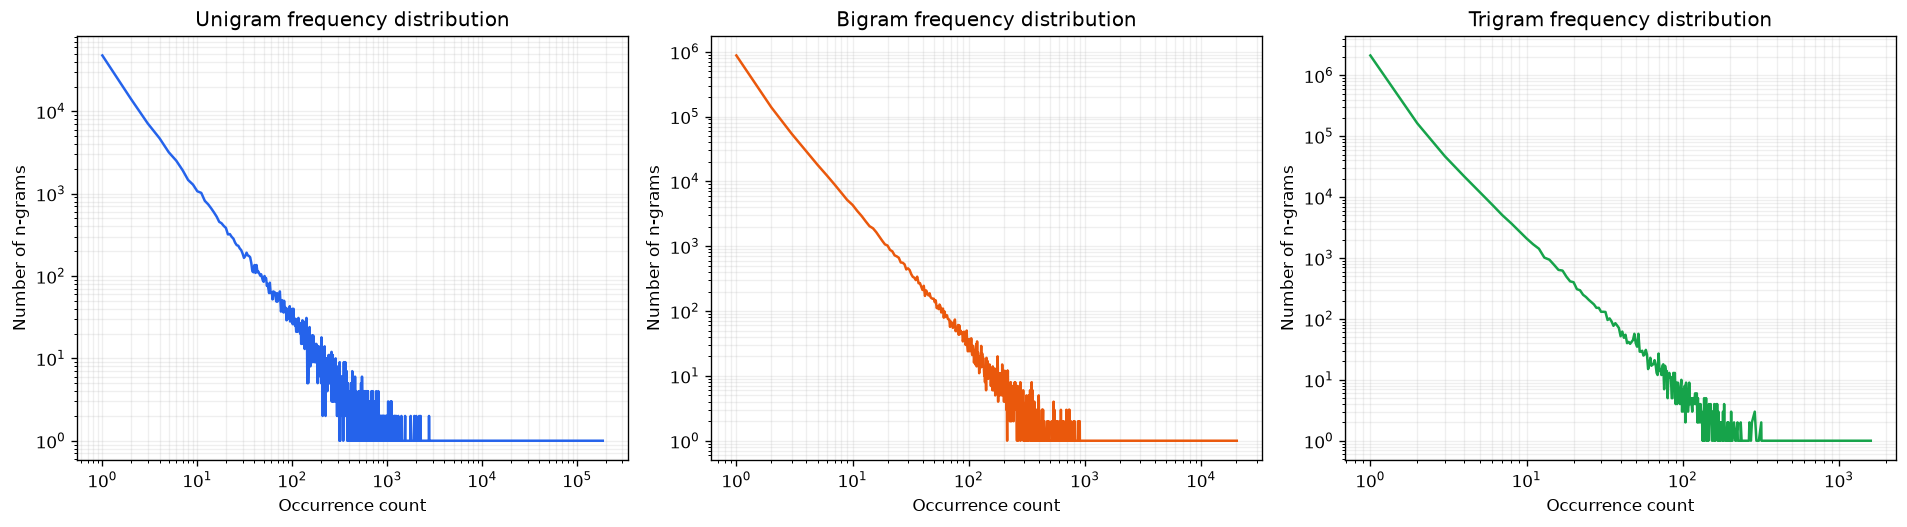

In [5]:
def show_frequency_plot(distributions):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    colors = {1: "#2563eb", 2: "#ea580c", 3: "#16a34a"}

    for axis, (n, label) in zip(axes, ((1, "Unigram"), (2, "Bigram"), (3, "Trigram"))):
        entries = sorted(distributions[n].items())
        occurrence_counts = [item[0] for item in entries]
        number_of_ngrams = [item[1] for item in entries]
        axis.plot(occurrence_counts, number_of_ngrams, color=colors[n], linewidth=1.5)
        axis.set_xscale("log")
        axis.set_yscale("log")
        axis.set_title(f"{label} frequency distribution")
        axis.set_xlabel("Occurrence count")
        axis.set_ylabel("Number of n-grams")
        axis.grid(True, which="both", alpha=0.2)

    fig.tight_layout()
    plt.show()


show_frequency_plot(frequency_distributions)


### Thảo luận Experiment 1

- Corpus 10.000 documents có 207.954 câu, 3.634.369 token và 102.718 từ khác nhau. Vocabulary đếm từ đơn nên không tăng chỉ vì chuyển sang bigram hoặc trigram.
- Số loại n-gram lần lượt là 102.718, 1.186.446 và 2.391.055. Chuỗi dài hơn tạo ra nhiều tổ hợp có thứ tự hơn.
- Tỉ lệ n-gram chỉ xuất hiện một lần tăng từ 46,37% ở unigram lên 73,63% ở bigram và 88,43% ở trigram. Điều này cho thấy dữ liệu trigram rất thưa.
- Trên biểu đồ log–log, nhiều loại n-gram nằm ở vùng tần suất thấp; chỉ ít loại lặp lại rất nhiều lần.


## 14. Core implementation

Các hàm build_vocabulary, count_ngrams, train_unigram, train_bigram, train_trigram và lớp NGramLanguageModel nằm trong ngram_lm.py, được tự cài đặt bằng Python. Ví dụ nhỏ dưới đây kiểm tra cách đếm và xác suất có điều kiện trước khi huấn luyện trên corpus 10k.


In [6]:
from ngram_lm import count_ngrams

demo_corpus = [["the", "cat", "eats", "fish"], ["the", "dog", "eats", "meat"]]
demo_model = NGramLanguageModel(n=2, smoothing="mle").fit(demo_corpus)
show_table(pd.DataFrame({
    "Đại lượng": ["Vocabulary", "Unigram the", "Bigram the cat",
                  "Trigram the cat eats", "P(cat | the)", "P(the cat eats fish)"],
    "Giá trị": [
        ", ".join(build_vocabulary(demo_corpus, include_special_tokens=False)),
        train_unigram(demo_corpus)[("the",)],
        train_bigram(demo_corpus)[("the", "cat")],
        train_trigram(demo_corpus)[("the", "cat", "eats")],
        demo_model.probability(["the"], "cat"),
        demo_model.sentence_probability(["the", "cat", "eats", "fish"]),
    ],
}))
print("count_ngrams trên câu đầu:", count_ngrams(demo_corpus[0], 2))
print("Từ tiếp theo sau 'the':", list(demo_model.next_word_distribution("the").items())[:3])


              Đại lượng                          Giá trị
0            Vocabulary  cat, dog, eats, fish, meat, the
1           Unigram the                                2
2        Bigram the cat                                1
3  Trigram the cat eats                                1
4          P(cat | the)                              0.5
5  P(the cat eats fish)                           0.0625


count_ngrams trên câu đầu:
 
Counter({('the', 'cat'): 1, ('cat', 'eats'): 1, ('eats', 'fish'): 1})

Từ tiếp theo sau 'the':
 
[('cat', 0.5), ('dog', 0.5)]



## 15. Log probability

Tích của nhiều xác suất nhỏ có thể làm số thực máy tính tràn xuống 0. Cộng log xác suất giữ được thông tin để tính perplexity. Giá trị 0 của sentence_probability trong ví dụ dài dưới đây là hiệu ứng số học; log probability vẫn hữu hạn.


In [7]:
demo_unigram = NGramLanguageModel(n=1, smoothing="mle").fit(demo_corpus)
long_sentence = ["the", "cat", "eats", "fish"] * 100
show_table(pd.DataFrame([{
    "Số token": len(long_sentence),
    "Sentence probability": demo_unigram.sentence_probability(long_sentence),
    "Log probability": demo_unigram.sentence_log_probability(long_sentence),
}]))


   Số token  Sentence probability  Log probability
0       400         9.332636e-302      -693.147181


## 16. Experiment 2 — MLE vs Laplace smoothing

Huấn luyện bigram và trigram trên train; đánh giá MLE và Laplace trên cùng train, validation, test. Từ ngoài vocabulary của train được ánh xạ về UNK. Một xác suất bằng 0 làm perplexity toàn tập của MLE bằng vô hạn.


In [8]:
split_summary = pd.DataFrame([
    {"Split": "Train", "Documents": len(train_documents), "Sentences": len(train_sentences)},
    {"Split": "Validation", "Documents": len(validation_documents), "Sentences": len(validation_sentences)},
    {"Split": "Test", "Documents": len(test_documents), "Sentences": len(test_sentences)},
])
show_table(split_summary)


        Split  Documents  Sentences
0       Train       7000     145151
1  Validation       1500      31255
2        Test       1500      31548


In [9]:
splits = {
    "train": train_sentences,
    "validation": validation_sentences,
    "test": test_sentences,
}
trained_models = {}
experiment2_results = []

for n, label in ((2, "Bigram"), (3, "Trigram")):
    model = NGramLanguageModel(n=n, smoothing="mle").fit(train_sentences)
    trained_models[n] = model
    for smoothing in ("mle", "laplace"):
        model.smoothing = smoothing
        scores = {split: model.perplexity(sentences) for split, sentences in splits.items()}
        experiment2_results.append({
            "Model": f"{label} {smoothing.title()}",
            "Train_PPL": scores["train"],
            "Valid_PPL": scores["validation"],
            "Test_PPL": scores["test"],
        })
        for split, score in scores.items():
            add_result("perplexity", "Experiment 2", label, n, smoothing, split, perplexity=score)
    model.smoothing = "mle"

print("Model                 Train PPL       Valid PPL        Test PPL")
for row in experiment2_results:
    print(f"{row['Model']:<20} {row['Train_PPL']:>12.4f} {row['Valid_PPL']:>15.4f} {row['Test_PPL']:>15.4f}")
experiment2_table = pd.DataFrame(experiment2_results)
show_table(experiment2_table.round(4))


Model                 Train PPL       Valid PPL        Test PPL

Bigram Mle               133.7667             inf             inf

Bigram Laplace          5933.0691       8553.3568       8688.7404

Trigram Mle               10.4365             inf             inf

Trigram Laplace        20681.1928      36847.8795      37053.1090



             Model   Train_PPL   Valid_PPL    Test_PPL
0       Bigram Mle    133.7667         inf         inf
1   Bigram Laplace   5933.0691   8553.3568   8688.7404
2      Trigram Mle     10.4365         inf         inf
3  Trigram Laplace  20681.1928  36847.8795  37053.1090


### Thảo luận Experiment 2

- Bigram MLE đạt train PPL 133,77 và trigram MLE đạt 10,44. Cả hai cho validation/test PPL bằng vô hạn vì gặp n-gram chưa có trong train.
- Laplace cho điểm hữu hạn. Bigram Laplace có validation/test PPL 8.553,36 / 8.688,74; trigram Laplace là 36.847,88 / 37.053,11. Trên corpus 10k này, bigram Laplace đạt điểm thấp hơn trigram Laplace trên dữ liệu chưa thấy.
- Laplace cũng làm train PPL tăng vì phân bổ một phần xác suất cho các từ chưa xuất hiện sau context. Khi trigram rất thưa, sự phân bổ này tạo ra PPL cao.
- Test PPL hơi cao hơn validation ở cả hai model Laplace.


## 17. Perplexity

Perplexity = exp(− tổng log P(từ | context) / tổng số từ cần dự đoán). Giá trị thấp hơn cho thấy model gán xác suất lớn hơn cho chính tập đánh giá đó. Chỉ so sánh PPL khi các model dùng cùng dữ liệu, cùng tiền xử lý và cùng cách đếm token. Notebook này không cộng EOS vào mẫu số.


## 18. Bài tập tính Perplexity

Ví dụ của W2: P(w1) = 0,5; P(w2 | w1) = 0,25; P(w3 | w2) = 0,5. Cell tính bằng code để đối chiếu; phần trình bày phép tính tay nằm trong calculations.md.


In [10]:
example_rows = []
for middle_probability in (0.25, 0.10):
    sentence_probability = 0.5 * middle_probability * 0.5
    example_rows.append({
        "P(w2 | w1)": middle_probability,
        "P(W)": sentence_probability,
        "PP(W)": sentence_probability ** (-1 / 3),
    })
show_table(pd.DataFrame(example_rows).round(4))


   P(w2 | w1)    P(W)   PP(W)
0        0.25  0.0625  2.5198
1        0.10  0.0250  3.4200


## 19. Experiment 3 — Perplexity theo bậc n-gram

So sánh unigram, bigram, trigram MLE trên cùng ba tập. Hai biểu đồ cho thấy train PPL và validation/test PPL; các giá trị vô hạn được ghi chữ inf vì không thể vẽ thành cột hữu hạn.


Model       Train PPL       Validation PPL       Test PPL

Unigram       2007.7645                inf            inf

Bigram         133.7667                inf            inf

Trigram         10.4365                inf            inf



     Model  Train_PPL  Validation_PPL  Test_PPL
0  Unigram  2007.7645             inf       inf
1   Bigram   133.7667             inf       inf
2  Trigram    10.4365             inf       inf


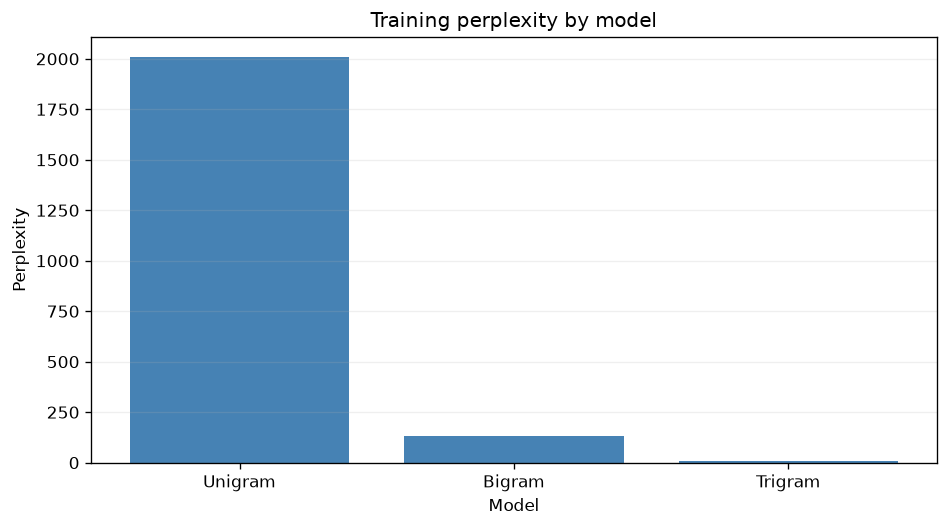

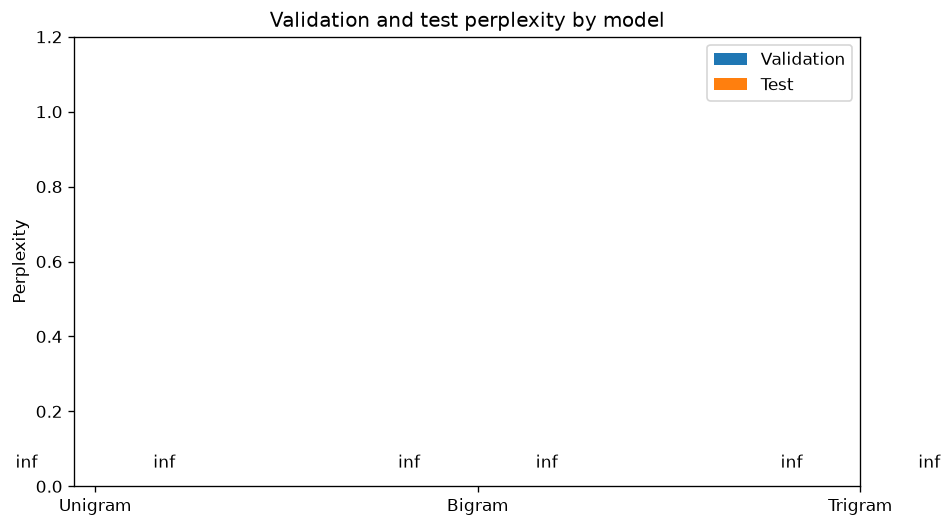

In [11]:
trained_models[1] = NGramLanguageModel(n=1, smoothing="mle").fit(train_sentences)
experiment3_results = []

for n, label in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram")):
    model = trained_models[n]
    model.smoothing = "mle"
    if n == 1:
        scores = {split: model.perplexity(sentences) for split, sentences in splits.items()}
    else:
        previous = next(row for row in experiment2_results
                        if row["Model"] == f"{label} Mle")
        scores = {"train": previous["Train_PPL"],
                  "validation": previous["Valid_PPL"],
                  "test": previous["Test_PPL"]}
    experiment3_results.append({
        "Model": label,
        "Train_PPL": scores["train"],
        "Validation_PPL": scores["validation"],
        "Test_PPL": scores["test"],
    })
    for split, score in scores.items():
        add_result("perplexity", "Experiment 3", label, n, "mle", split, perplexity=score)

print("Model       Train PPL       Validation PPL       Test PPL")
for row in experiment3_results:
    print(f"{row['Model']:<10} {row['Train_PPL']:>12.4f} {row['Validation_PPL']:>18.4f} {row['Test_PPL']:>14.4f}")

experiment3_table = pd.DataFrame(experiment3_results)
show_table(experiment3_table.round(4))

plt.figure(figsize=(8, 4.5))
plt.bar(
    [row["Model"] for row in experiment3_results],
    [row["Train_PPL"] for row in experiment3_results],
    color="#4682b4",
)
plt.title("Training perplexity by model")
plt.xlabel("Model")
plt.ylabel("Perplexity")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

validation_values = np.array([row["Validation_PPL"] for row in experiment3_results], dtype=float)
test_values = np.array([row["Test_PPL"] for row in experiment3_results], dtype=float)
positions = np.arange(len(experiment3_results))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(positions - 0.18, np.where(np.isfinite(validation_values), validation_values, np.nan),
       0.36, label="Validation")
ax.bar(positions + 0.18, np.where(np.isfinite(test_values), test_values, np.nan),
       0.36, label="Test")
finite_values = np.concatenate([validation_values[np.isfinite(validation_values)],
                                test_values[np.isfinite(test_values)]])
ax.set_ylim(0, max(finite_values, default=1) * 1.2)
for i, (valid, test) in enumerate(zip(validation_values, test_values)):
    if not np.isfinite(valid):
        ax.text(i - 0.18, 0.05, "inf", ha="center")
    if not np.isfinite(test):
        ax.text(i + 0.18, 0.05, "inf", ha="center")
ax.set_xticks(positions, [row["Model"] for row in experiment3_results])
ax.set_title("Validation and test perplexity by model")
ax.set_ylabel("Perplexity")
ax.legend()
fig.tight_layout()
plt.show()


### Thảo luận Experiment 3

- Train PPL giảm từ 2.007,76 (unigram) xuống 133,77 (bigram) và 10,44 (trigram). Context dài hơn khớp các chuỗi đã thấy trong train chặt hơn.
- Validation và test PPL đều vô hạn cho cả ba model MLE. Vì vậy train PPL thấp chưa chứng minh được model tổng quát hóa tốt.
- Tỉ lệ n-gram chưa thấy trong validation/test tăng từ khoảng 2,9% với unigram lên 33,4% với bigram và 74,0% với trigram. Đây là bằng chứng trực tiếp cho sparsity và khoảng cách train/test.
- Corpus 10k có ít cơ hội lặp lại context dài. Tăng dữ liệu có thể giúp quan sát thêm trigram, nhưng kết quả của lần chạy này không cho phép khẳng định trigram MLE tốt hơn trên dữ liệu mới.


## 20. Application — Next-word prediction

Ưu tiên phân phối từ tiếp theo của trigram MLE; nếu context trigram chưa có, dùng bigram MLE. Thử năm context và tra actual next word đầu tiên trong test.


the cat              house (0.1429), and (0.0714), at (0.0714)                         actual=queen

natural language     1980 (1.0000)                                                     actual=Unknown

machine learning     and (0.1923), based (0.1923), approaches (0.1538)                 actual=has

deep learning        and (0.5000), for (0.2500), technologies (0.2500)                 actual=Unknown

computer vision      based (0.3333), iccv (0.3333), soft (0.3333)                      actual=Unknown



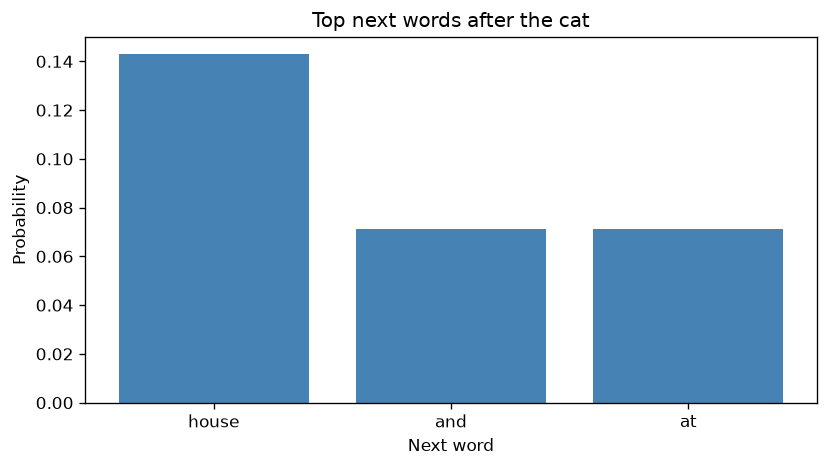

            Context                                         Prediction Actual next word
0           the cat          house (0.1429), and (0.0714), at (0.0714)            queen
1  natural language                                      1980 (1.0000)          Unknown
2  machine learning  and (0.1923), based (0.1923), approaches (0.1538)              has
3     deep learning  and (0.5000), for (0.2500), technologies (0.2500)          Unknown
4   computer vision       based (0.3333), iccv (0.3333), soft (0.3333)          Unknown


In [12]:
def predict_next_words(context, k=3):
    predictions = trained_models[3].next_word_distribution(context)
    if not predictions:
        predictions = trained_models[2].next_word_distribution(context)
    return list(predictions.items())[:k]


def find_actual_next_word(context, sentences):
    context_tokens = tokenize_sentence(context)
    for sentence in sentences:
        for start in range(len(sentence) - len(context_tokens)):
            if sentence[start:start + len(context_tokens)] == context_tokens:
                return sentence[start + len(context_tokens)]
    return "Unknown"


contexts = ["the cat", "natural language", "machine learning", "deep learning", "computer vision"]
prediction_rows = []
for context in contexts:
    top_words = predict_next_words(context)
    actual = find_actual_next_word(context, test_sentences)
    text = ", ".join(f"{word} ({probability:.4f})" for word, probability in top_words) or "No prediction"
    print(f"{context:<20} {text:<65} actual={actual}")
    for rank, (word, probability) in enumerate(top_words, start=1):
        row = {"context": context, "candidate": word, "rank": rank,
               "prediction": top_words[0][0], "actual_next_word": actual,
               "probability": probability}
        prediction_rows.append(row)
        add_result("next_word", "Application 1", "Trigram MLE", 3, "mle",
                   "test", context, word, rank, top_words[0][0], actual, probability)

chart_predictions = predict_next_words("the cat")
if chart_predictions:
    plt.figure(figsize=(7, 4))
    plt.bar(
        [word for word, _ in chart_predictions],
        [probability for _, probability in chart_predictions],
        color="#4682b4",
    )
    plt.title("Top next words after the cat")
    plt.xlabel("Next word")
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()

prediction_table_rows = []
for context in contexts:
    rows = [row for row in prediction_rows if row["context"] == context]
    prediction_text = ", ".join(
        f'{row["candidate"]} ({row["probability"]:.4f})' for row in rows
    ) or "No prediction"
    actual = rows[0]["actual_next_word"] if rows else find_actual_next_word(context, test_sentences)
    prediction_table_rows.append({
        "Context": context, "Prediction": prediction_text, "Actual next word": actual
    })
prediction_table = pd.DataFrame(prediction_table_rows)
show_table(prediction_table)


### Thảo luận Application 1

- Với the cat, từ có xác suất cao nhất là house nhưng actual đầu tiên tìm thấy trong test là queen. Với machine learning, dự đoán cao nhất là and còn actual là has.
- Ba context còn lại trả về Unknown ở cột actual vì không tìm thấy context trong test, nên không thể tính đúng/sai từ bảng này.
- Xác suất cao chỉ phản ánh tần suất trong train. Ví dụ natural language có dự đoán 1980 với xác suất 1,0 nhưng không có actual để đối chiếu. Một context cũng có thể có nhiều từ tiếp theo hợp lý; việc lấy lần xuất hiện đầu tiên trong test chỉ là minh họa.


## 21. Application — Sentence ranking

Chấm điểm ba candidate continuation theo tổng log xác suất của trigram MLE rồi xếp hạng giảm dần. Candidate có log probability gần 0 hơn được model ưu tiên.


In [13]:
ranking_context = ["machine", "learning"]
context_tuple = tuple(ranking_context)
continuation_counts = Counter()
for sentence in train_sentences:
    for start in range(len(sentence) - len(context_tuple)):
        if tuple(sentence[start:start + len(context_tuple)]) == context_tuple:
            continuation = sentence[start + len(context_tuple):start + len(context_tuple) + 3]
            if continuation:
                continuation_counts[" ".join(continuation)] += 1

candidates = [text for text, _ in continuation_counts.most_common(3)]
if not candidates:
    candidates = ["is useful for", "models are used", "works very well"]


def score_continuation(model, context, text):
    history = list(context)
    score = 0.0
    for word in tokenize_sentence(text):
        probability = model.probability(history, word)
        if probability == 0:
            return -math.inf
        score += math.log(probability)
        history.append(word)
    return score


ranking_rows = [(text, score_continuation(trained_models[3], ranking_context, text))
                for text in candidates]
ranking_rows.sort(key=lambda row: row[1], reverse=True)
for rank, (text, score) in enumerate(ranking_rows, start=1):
    print(f"{rank}. {text} | log P={score:.6f}")
    add_result("sentence_ranking", "Application 2", "Trigram MLE", 3, "mle",
               "train", " ".join(ranking_context), text, rank, notes=f"log_probability={score}")
ranking_table = pd.DataFrame([
    {"Rank": rank, "Candidate": text, "Log probability": score}
    for rank, (text, score) in enumerate(ranking_rows, start=1)
])
show_table(ranking_table.round(4))


1. models | log P=-1.871802

2. and sandboxing to | log P=-5.232178

3. technology and is | log P=-7.853216



   Rank          Candidate  Log probability
0     1             models          -1.8718
1     2  and sandboxing to          -5.2322
2     3  technology and is          -7.8532


### Thảo luận Application 2

- Với context machine learning, candidate models đứng đầu với log probability −1,8718; hai candidate còn lại đạt −5,2322 và −7,8532.
- Ba candidate được lấy từ training data, nên thứ hạng này mô tả sự ưu tiên của model trên đúng tập candidate đã chọn. Nó chưa đo chất lượng câu một cách độc lập.


## 22. Error analysis

Cell dưới đây chọn tự động hai ví dụ dự đoán đúng và hai ví dụ dự đoán sai từ test, với điều kiện context trigram đã xuất hiện trong train. Bảng là bằng chứng để ghi nguyên nhân cụ thể vào error_analysis.md.


In [14]:
model = trained_models[3]
wanted = {}
for sentence in test_sentences:
    for position in range(2, len(sentence)):
        pair = tuple(sentence[position - 2:position])
        if any(word not in model.word_id for word in pair):
            continue
        key = model._encode([model.word_id[word] for word in pair])
        if key not in wanted:
            wanted[key] = (pair, sentence[position])
        if len(wanted) >= 2000:
            break
    if len(wanted) >= 2000:
        break

best = {}
for key, count in model.trigram_counts.items():
    context_key, word_id = divmod(key, model.base)
    if context_key not in wanted:
        continue
    previous = best.get(context_key)
    if previous is None or count > previous[0] or (
        count == previous[0] and model.vocabulary[word_id] < model.vocabulary[previous[1]]
    ):
        best[context_key] = (count, word_id)

correct, incorrect = [], []
for context_key, (pair, actual) in wanted.items():
    if context_key not in best:
        continue
    count, word_id = best[context_key]
    predicted = model.vocabulary[word_id]
    row = {
        "Kết quả": "Đúng" if predicted == actual else "Sai",
        "Context": " ".join(pair),
        "Prediction": predicted,
        "Actual next word": actual,
        "Probability": count / model.trigram_context_counts[context_key],
    }
    target = correct if predicted == actual else incorrect
    if len(target) < 2:
        target.append(row)
    if len(correct) == 2 and len(incorrect) == 2:
        break

error_case_table = pd.DataFrame(correct + incorrect)
show_table(error_case_table)
for row in correct + incorrect:
    add_result("error_case", "Error analysis", "Trigram", 3, "mle", "test",
               row["Context"], row["Prediction"], prediction=row["Prediction"],
               actual_next_word=row["Actual next word"],
               probability=row["Probability"], notes=row["Kết quả"])


  Kết quả                 Context Prediction Actual next word  Probability
0    Đúng             alliance is          a                a     0.500000
1    Đúng  nonprofit organization  dedicated        dedicated     0.166667
2     Sai            the downtown       area         alliance     0.500000
3     Sai                    is a      great            501c6     0.035685


## 23. Thí nghiệm context length

Đối chiếu train/validation/test PPL ở Experiment 3 với số n-gram duy nhất và tỉ lệ n-gram chưa xuất hiện trong train. Bảng dưới đây bổ sung bằng chứng cho nhận xét về độ dài context.


Model       Split        Unseen       Total      Unseen rate

Unigram    train               0   2,524,517 0.0000%

Unigram    validation     16,208     554,270 2.9242%

Unigram    test           15,887     555,582 2.8595%

Bigram     train               0   2,379,366 0.0000%

Bigram     validation    175,036     523,015 33.4667%

Bigram     test          174,862     524,034 33.3684%

Trigram    train               0   2,237,193 0.0000%

Trigram    validation    364,843     492,265 74.1152%

Trigram    test          365,087     493,035 74.0489%

Saved 50 rows to D:\NLP_exercise\lab2\results.csv



     Model       Split  Unseen    Total  Unseen rate
0  Unigram       train       0  2524517     0.000000
1  Unigram  validation   16208   554270     0.029242
2  Unigram        test   15887   555582     0.028595
3   Bigram       train       0  2379366     0.000000
4   Bigram  validation  175036   523015     0.334667
5   Bigram        test  174862   524034     0.333684
6  Trigram       train       0  2237193     0.000000
7  Trigram  validation  364843   492265     0.741152
8  Trigram        test  365087   493035     0.740489


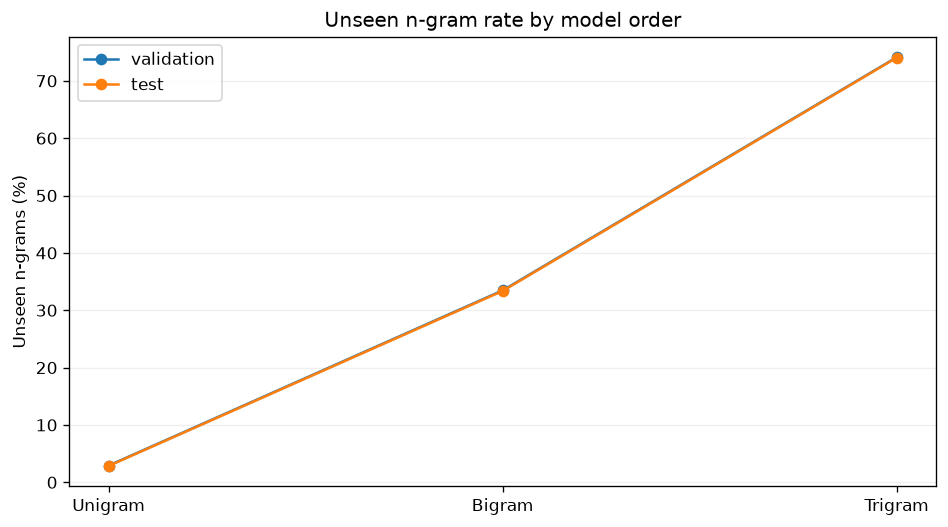

In [15]:
print("Model       Split        Unseen       Total      Unseen rate")
for n, label in ((1, "Unigram"), (2, "Bigram"), (3, "Trigram")):
    model = trained_models[n]
    for split, sentences in splits.items():
        coverage = model.ngram_coverage(sentences)
        print(f"{label:<10} {split:<10} {coverage['unseen_ngrams']:>10,} {coverage['total_ngrams']:>11,} {coverage['unseen_rate']:.4%}")
        add_result("ngram_coverage", "Experiment 23", label, n, "mle", split,
                   probability=coverage["unseen_rate"],
                   notes=f"unseen={coverage['unseen_ngrams']}; total={coverage['total_ngrams']}")

with RESULTS_PATH.open("w", encoding="utf-8", newline="") as stream:
    writer = csv.DictWriter(stream, fieldnames=RESULT_COLUMNS)
    writer.writeheader()
    writer.writerows(all_result_rows)
print(f"Saved {len(all_result_rows)} rows to {RESULTS_PATH}")
coverage_table = pd.DataFrame([
    {"Model": row["model"], "Split": row["split"],
     "Unseen": int(row["notes"].split(";")[0].split("=")[1]),
     "Total": int(row["notes"].split(";")[1].split("=")[1]),
     "Unseen rate": float(row["probability"])}
    for row in all_result_rows if row["record_type"] == "ngram_coverage"
])
show_table(coverage_table)
fig, ax = plt.subplots(figsize=(8, 4.5))
for split in ("validation", "test"):
    subset = coverage_table[coverage_table["Split"] == split]
    ax.plot(subset["Model"], subset["Unseen rate"] * 100, marker="o", label=split)
ax.set_ylabel("Unseen n-grams (%)")
ax.set_title("Unseen n-gram rate by model order")
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()


### Thảo luận context length

- Training có unseen rate bằng 0 vì chính tập đó dùng để fit model. Trên test, khoảng 2,86% unigram, 33,37% bigram và 74,05% trigram chưa xuất hiện trong train.
- Context dài hơn làm train PPL giảm mạnh nhưng số tổ hợp chưa thấy tăng rất nhanh. Trên corpus 10k này, chưa có bằng chứng rằng tăng n luôn tốt hơn trên dữ liệu mới.


## 25. AI assistance statement

- Công cụ: Codex.
- Mục đích: hỗ trợ cài đặt mã, dựng bảng/biểu đồ và soạn bản nháp nhận xét tiếng Việt.
- Nội dung đã tạo: notebook thí nghiệm, phần mã hỗ trợ và các đoạn thảo luận dựa trên kết quả corpus 10k.
- Nội dung sinh viên tự chỉnh sửa: các đánh giá nhận xét
- Cách kiểm tra: đã chạy đủ 16 code cell; notebook có các bảng kết quả, 5 biểu đồ inline và results.csv có 50 dòng kết quả. Sinh viên kiểm tra lại trên môi trường nộp bài.
